In [33]:
import pandas as pd
df = pd.read_csv("bank.csv")
print(df.shape)
df.head()  

(11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [34]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [36]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [37]:
missing_values = df.isnull().sum()
print("Missing values per column:")
missing_values

Missing values per column:


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [38]:
duplicates = df.duplicated().sum()

print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


In [39]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (11162, 17)


In [40]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [41]:
df["deposit"].value_counts()

deposit
no     5873
yes    5289
Name: count, dtype: int64

In [42]:
target_percentage = df["deposit"].value_counts(normalize=True) * 100

target_percentage

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64

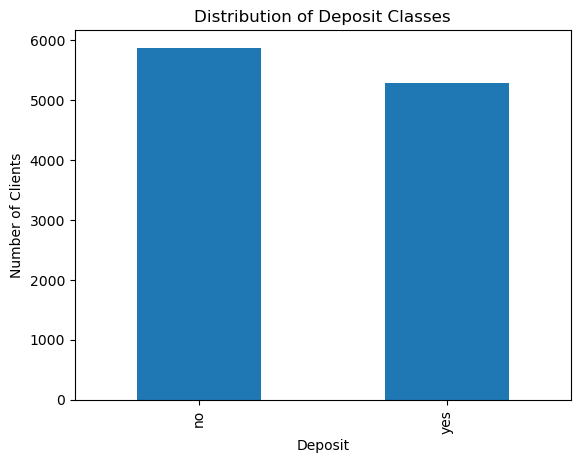

In [43]:
df["deposit"].value_counts().plot(kind="bar")

plt.title("Distribution of Deposit Classes")
plt.xlabel("Deposit")
plt.ylabel("Number of Clients")
plt.show()

In [46]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numeric columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numeric columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [47]:
for column in categorical_columns:
    print("=" * 50)
    print(column)
    print(df[column].value_counts().head(10))

job
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
Name: count, dtype: int64
marital
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
education
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
default
default
no     10994
yes      168
Name: count, dtype: int64
housing
housing
no     5881
yes    5281
Name: count, dtype: int64
loan
loan
no     9702
yes    1460
Name: count, dtype: int64
contact
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64
month
month
may    2824
aug    1519
jul    1514
jun    1222
nov     943
apr     923
feb     776
oct     392
jan     344
sep     319
Name: count, dtype: int64
poutcome
poutcome
unknown    8326
failure    1228
success    1071
other       537
Name:

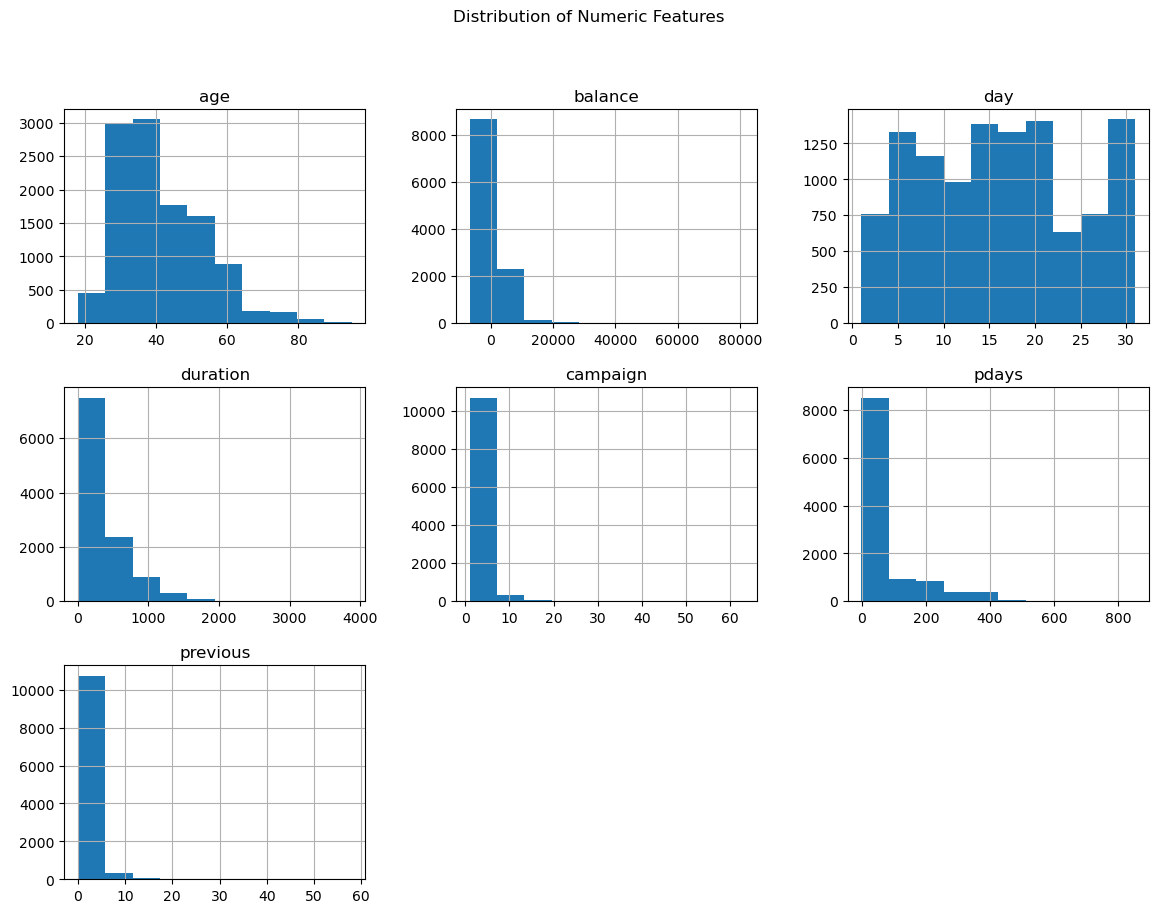

In [50]:
df[numeric_columns].hist(figsize=(14, 10))

plt.suptitle("Distribution of Numeric Features")
plt.show()

In [49]:
correlation_matrix = df[numeric_columns].corr()
correlation_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.112300,-0.000762,0.000189,-0.005278,0.002774,0.020169
balance,0.112300,1.000000,0.010467,0.022436,-0.013894,0.017411,0.030805
day,-0.000762,0.010467,1.000000,-0.018511,0.137007,-0.077232,-0.058981
duration,0.000189,0.022436,-0.018511,1.000000,-0.041557,-0.027392,-0.026716
campaign,-0.005278,-0.013894,0.137007,-0.041557,1.000000,-0.102726,-0.049699
pdays,0.002774,0.017411,-0.077232,-0.027392,-0.102726,1.000000,0.507272
previous,0.020169,0.030805,-0.058981,-0.026716,-0.049699,0.507272,1.000000


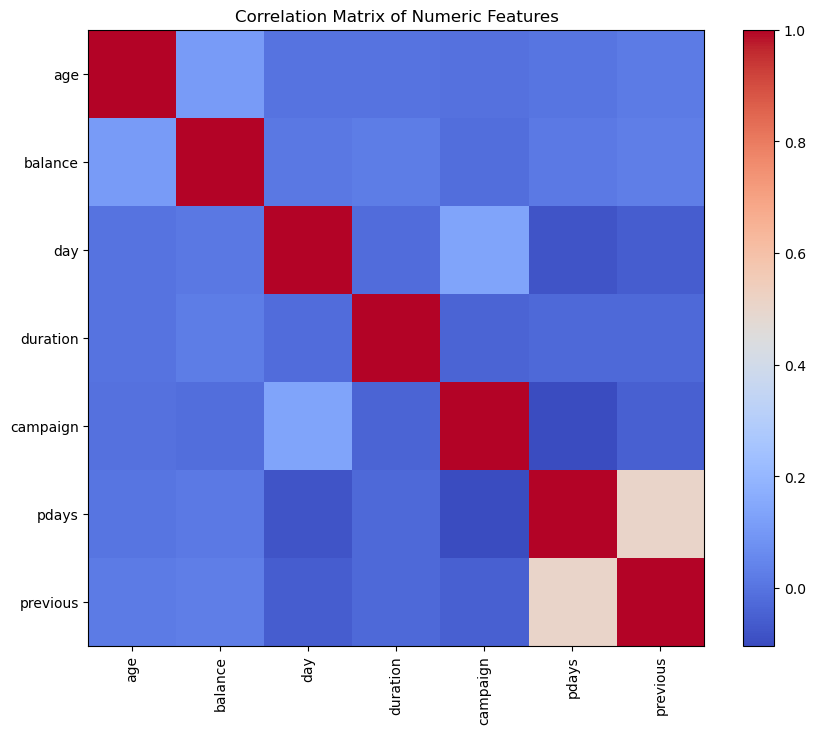

In [55]:
plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [56]:
target = "deposit"

X = df.drop(columns=[target])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11162, 16)
y shape: (11162,)


In [57]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)
print("Encoded target example:", y_encoded[:10])

Classes: ['no' 'yes']
Encoded target example: [1 1 1 1 1 1 1 1 1 1]


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8929, 16)
X_test shape: (2233, 16)
y_train shape: (8929,)
y_test shape: (2233,)


In [60]:
print("Train target distribution:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

Train target distribution:
0    52.615074
1    47.384926
Name: proportion, dtype: float64

Test target distribution:
0    52.619794
1    47.380206
Name: proportion, dtype: float64
